<a href="https://colab.research.google.com/github/manyasachdeva27/MACHINE-LEARNING/blob/main/Outlier_detection_and_removal_using_IQR_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
df=pd.read_csv('/content/placement (1).csv')

In [87]:
df.sample(5)

,cgpa,placement_exam_marks,placed
10,6.82,16.0,1
168,6.51,37.0,1
670,7.51,17.0,1
247,6.25,49.0,0
231,6.40,35.0,0


/tmp/ipython-input-362/2646171464.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'],hist=False)
/tmp/ipython-input-362/2646171464.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'],hist=False)


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

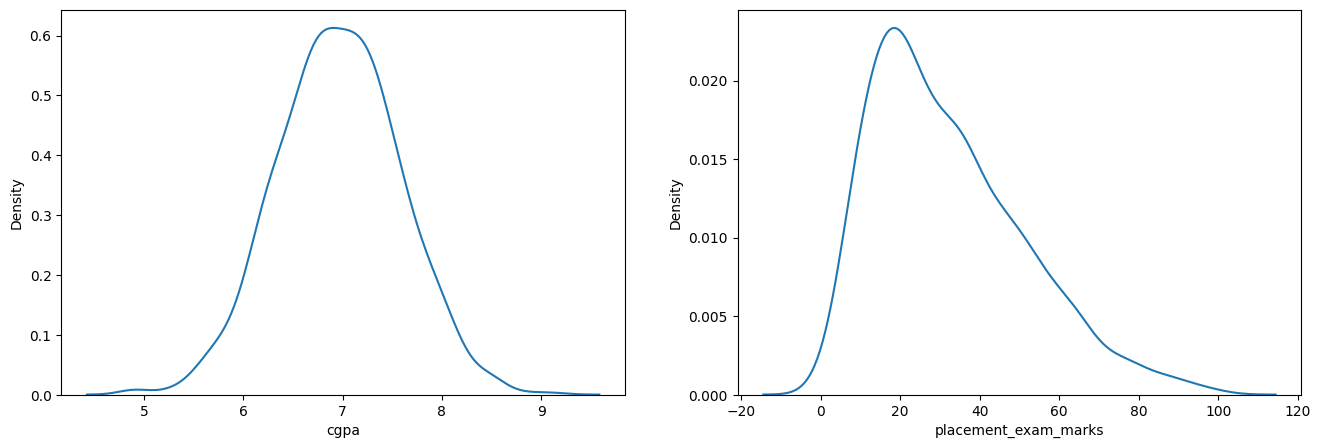

In [88]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'],hist=False)

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'],hist=False)

In [89]:
#another method for skewness

#df['cgpa'].skew()
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [90]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


<Axes: ylabel='placement_exam_marks'>

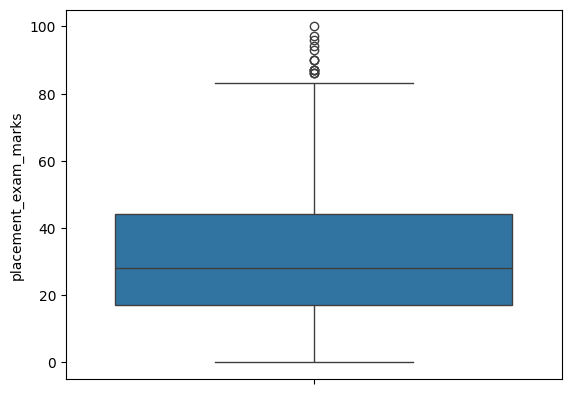

In [91]:
#outlier detection

sns.boxplot(df['placement_exam_marks'])

In [92]:
#outlier removal

Q1_percentile25=df['placement_exam_marks'].quantile(0.25)
Q3_percentile75=df['placement_exam_marks'].quantile(0.75)

In [93]:
Q1_percentile25

np.float64(17.0)

In [94]:
Q3_percentile75

np.float64(44.0)

In [95]:
IQR=Q3_percentile75-Q1_percentile25

In [96]:
IQR

np.float64(27.0)

In [97]:
maximum_100percentile=Q3_percentile75+1.5*IQR
minimum_0percentile=Q1_percentile25-1.5*IQR

In [98]:
df[df['placement_exam_marks']<minimum_0percentile]

,cgpa,placement_exam_marks,placed


In [99]:
df[df['placement_exam_marks']>maximum_100percentile]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [100]:
df[(df['placement_exam_marks'] < maximum_100percentile) & (df['placement_exam_marks'] > minimum_0percentile)]

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [102]:
#capping

df['placement_exam_marks']=np.where(df['placement_exam_marks']>maximum_100percentile,maximum_100percentile,np.where(df['placement_exam_marks']<minimum_0percentile,minimum_0percentile,df['placement_exam_marks']))

In [104]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


<Axes: ylabel='placement_exam_marks'>

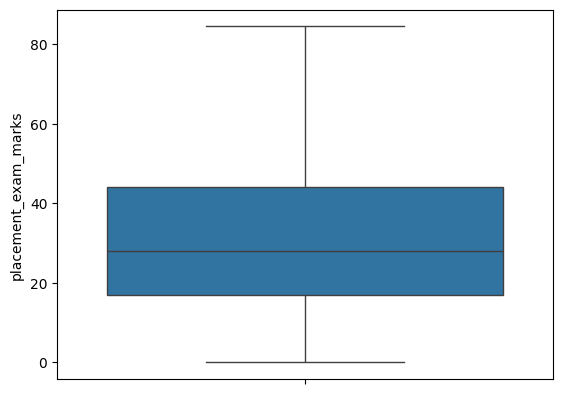

In [107]:
sns.boxplot(df['placement_exam_marks'])